# Netflix Data: Cleaning, Analysis and Visualization

# Problem Statement

Netflix offers a vast collection of movies and TV shows across different genres, countries, and release years. Analyzing this content can provide valuable insights into viewing trends, content distribution, and platform growth. This project aims to perform exploratory data analysis and develop machine learning models to identify patterns in Netflix content and support data-driven decisions related to content strategy and audience preferences.

# Tools Used

## Python

## Pandas

## NumPy

## Matplotlib

## Seaborn

## Plotly

## Scikit-learn

Used for:

- LabelEncoder
- train_test_split
- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier
- Accuracy Score
- Classification Report
- Confusion Matrix

## Jupyter Notebook

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


In [ ]:
df = pd.read_csv("/content/netflix1.csv")
df.head()


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [ ]:
df.info()
df.shape


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB


(8790, 10)

In [ ]:
df.isnull().sum()


,0
show_id,0
type,0
title,0
director,0
country,0
date_added,0
release_year,0
rating,0
duration,0
listed_in,0


In [ ]:
df.drop_duplicates(inplace=True)


In [ ]:
df['date_added'] = pd.to_datetime(df['date_added'])


In [ ]:
df['director'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)


/tmp/ipython-input-3653786316.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('Unknown', inplace=True)
/tmp/ipython-input-3653786316.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

In [ ]:
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month


In [ ]:
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(int)


<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-3750281618.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['duration_num'] = df['duration'].str.extract('(\d+)').astype(int)


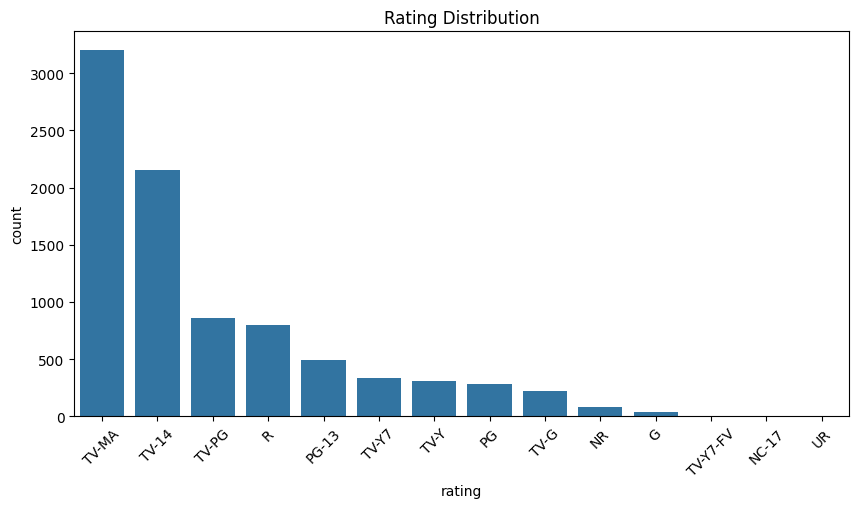

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='rating', order=df['rating'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Rating Distribution")
plt.show()


### Rating Distribution

#### Key Findings

The rating distribution analysis shows that **TV-MA** is the most common content rating on Netflix, followed by **TV-14**. This indicates that a large portion of Netflix's content is targeted toward mature and teenage audiences. Family-oriented categories such as G and PG represent a smaller percentage of the overall catalog, highlighting Netflix's stronger focus on adult entertainment content.

#### Business Insight

The dominance of mature-rated content suggests that Netflix primarily caters to adult viewers. Understanding audience preferences can help the company make informed decisions regarding future content acquisition and production strategies.






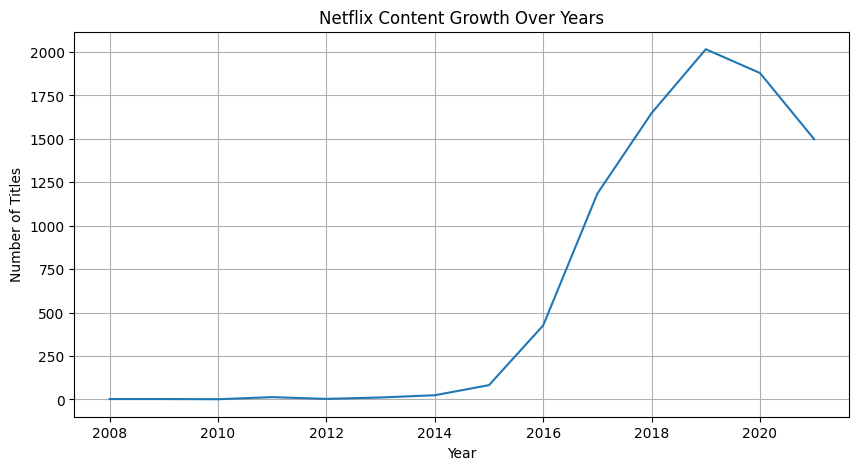

In [ ]:
yearly_content = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.plot(yearly_content.index, yearly_content.values)
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.title("Netflix Content Growth Over Years")
plt.grid(True)
plt.show()


Netflix Content Growth Over Years
Key Findings

The content growth trend demonstrates a significant increase in the number of titles added to Netflix between 2016 and 2019. The platform reached its highest level of content additions in 2019, reflecting a period of aggressive expansion and investment in content acquisition. This growth helped Netflix strengthen its position as one of the world's leading streaming platforms.

Business Insight

The rapid expansion of Netflix's content library indicates the company's commitment to attracting and retaining subscribers. Continued investment in diverse content can help maintain competitive advantage in the streaming market.

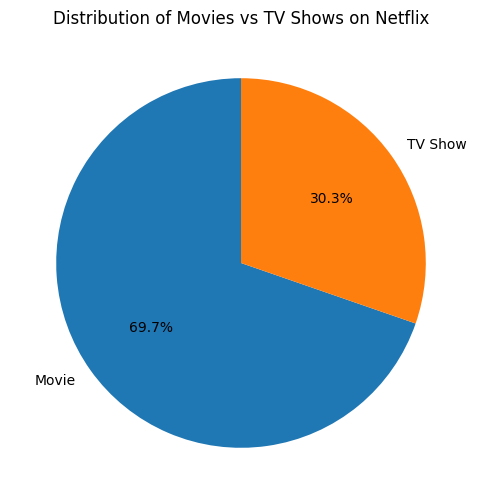

In [ ]:
type_counts = df['type'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Distribution of Movies vs TV Shows on Netflix")
plt.show()


Distribution of Movies vs TV Shows

Key Findings

The analysis reveals that Movies account for approximately 69.7% of Netflix's content library, while TV Shows contribute around 30.3%. This indicates that Netflix maintains a larger collection of movies to provide variety and meet diverse viewer preferences. However, TV Shows remain an important component of the platform due to their ability to generate long-term viewer engagement.

Business Insight

Maintaining a balanced mix of movies and TV shows enables Netflix to serve different audience segments while maximizing viewer retention and platform engagement.

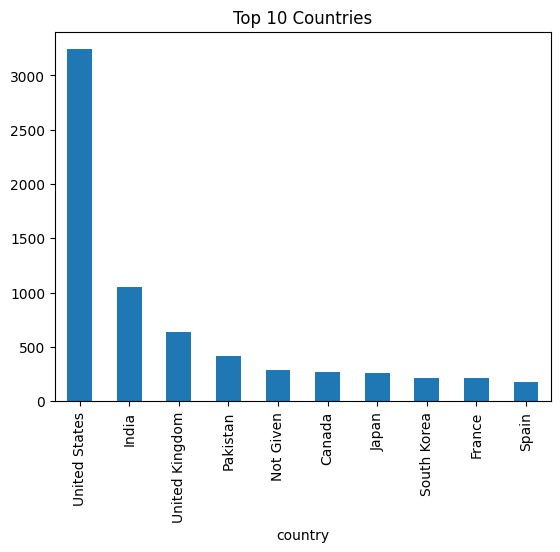

In [ ]:
df['country'].value_counts().head(10).plot(kind='bar', title='Top 10 Countries')
plt.show()


Top 10 Countries

Key Findings

The country-wise analysis shows that the United States contributes the highest number of titles to Netflix, followed by India and the United Kingdom. The dominance of these countries reflects their strong entertainment industries and significant content production capabilities. The results also highlight Netflix's global strategy of incorporating content from multiple regions to serve a diverse international audience.

Business Insight

Expanding investments in international markets can help Netflix reach new audiences and strengthen its global content portfolio while reducing dependence on a single market.

In [ ]:
features = df[['release_year', 'duration_num', 'year_added', 'month_added', 'rating', 'listed_in', 'country']]
target = df['type']


In [ ]:
le = LabelEncoder()

for col in ['rating', 'listed_in', 'country']:
    features[col] = le.fit_transform(features[col])


/tmp/ipython-input-2130576370.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features[col] = le.fit_transform(features[col])
/tmp/ipython-input-2130576370.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features[col] = le.fit_transform(features[col])
/tmp/ipython-input-2130576370.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pan

In [ ]:
target = le.fit_transform(target)  # Movie=0, TV Show=1


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)


In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", acc_lr)


Logistic Regression Accuracy: 0.9965870307167235


Logistic Regression Model
Key Findings
The Logistic Regression model achieved an accuracy of 99.66%, demonstrating excellent performance in classifying Netflix content as either a Movie or a TV Show. The high accuracy indicates that features such as release year, duration, rating, genre, and country provide strong predictive information for distinguishing between the two content types.
Business Insight
The model can support automated content categorization and reduce manual effort in managing large streaming libraries. Accurate classification improves content organization and enhances user experience by ensuring titles are grouped correctly.

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", acc_rf)


Random Forest Accuracy: 0.9977246871444824


Random Forest Model
Key Findings
The Random Forest model achieved an accuracy of 99.77%, slightly outperforming Logistic Regression. By combining multiple decision trees, the model was able to capture complex relationships among content features and deliver highly accurate predictions. The results indicate that the selected variables are highly effective in identifying content type.
Business Insight
The strong performance of Random Forest makes it a valuable tool for content management systems. Automated classification can improve recommendation engines, search functionality, and overall platform efficiency.

In [ ]:
print("Random Forest Classification Report")
print(classification_report(y_test, y_pred_rf))


Random Forest Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1238
           1       0.99      1.00      1.00       520

    accuracy                           1.00      1758
   macro avg       1.00      1.00      1.00      1758
weighted avg       1.00      1.00      1.00      1758



Classification Report

Key Findings

The classification report shows exceptionally strong model performance across both classes. Precision, Recall, and F1-Score values are close to 1.00 for both Movies and TV Shows, indicating that the model correctly identifies content types with very few misclassifications. The overall accuracy of nearly 100% confirms the reliability of the Random Forest model.

Business Insight

High classification accuracy enables Netflix to organize content more effectively, improve recommendation quality, and deliver a better viewing experience by ensuring content is categorized correctly.

In [ ]:
new_input = [[
    2020,   # release_year
    120,    # duration_num
    2021,   # year_added
    9,      # month_added
    3,      # rating (encoded)
    5,      # genre (encoded)
    10      # country (encoded)
]]

prediction = rf.predict(new_input)
print("Prediction:", "TV Show" if prediction[0]==1 else "Movie")


Prediction: Movie


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Prediction Analysis

Key Findings

The trained Random Forest model predicted the sample input as a Movie based on the provided attributes, including release year, duration, rating, genre, and country. This demonstrates the model's ability to classify new content using learned patterns from historical Netflix data.

Business Insight

Predictive models can automate content classification for newly added titles, helping streaming platforms manage large-scale content libraries more efficiently and consistently.

Conclusion

Key Findings

This project successfully applied data preprocessing, exploratory data analysis, and machine learning techniques to the Netflix dataset. The analysis revealed important insights regarding content ratings, content growth trends, content types, and country contributions. Both Logistic Regression and Random Forest achieved outstanding performance, with Random Forest producing the highest accuracy of 99.77%.

Business Insight

The results demonstrate how machine learning can support content management, recommendation systems, and business decision-making in streaming platforms. Accurate classification models enable efficient organization of content libraries while improving user engagement and operational effectiveness.